In [1]:
# =============================================
# Notebook 02 - System Identification
# Mass-Spring-Damper System
# =============================================

import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.model import MassSpringDamper
from src.visualization import Visualizer
from src.identification import SystemIdentifier

# Plot settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Notebook 02 - System Identification loaded successfully!")

✅ Notebook 02 - System Identification loaded successfully!


In [2]:
# Create identifier
identifier = SystemIdentifier()

# Generate data with measurement noise
df = identifier.generate_data(
    m_true=1.0,
    k_true=10.0,
    c_true=2.0,
    noise_level=0.015,   # 1.5% noise
    t_max=30.0
)

# Display first few rows
print("\nFirst 5 rows of generated data:")
display(df.head())

# Basic statistics
print(f"\nData shape: {df.shape}")
print(f"Noise level: ±{0.015*100:.1f}%")

🔄 Generating simulated data with noise...
✅ Data saved to: data\simulated_data.csv
   Noise level: ±1.5% | Samples: 2000

First 5 rows of generated data:


,time,input,position,position_true
0,0.000000,0.0,0.007451,0.0
1,0.015008,0.0,-0.002074,0.0
2,0.030015,0.0,0.009715,0.0
3,0.045023,0.0,0.022845,0.0
4,0.060030,0.0,-0.003512,0.0



Data shape: (2000, 4)
Noise level: ±1.5%


In [ ]:
# Cell 3: Parameter Identification (improved version)

# Generate data with less noise for better identification
df = identifier.generate_data(
    m_true=1.0,
    k_true=10.0,
    c_true=2.0,
    noise_level=0.005,   # reduced from 0.02 to 0.005
    t_max=30.0,
    seed=42
)

# Perform identification
m_est, c_est, k_est, cost = identifier.identify_parameters(
    df, 
    initial_guess=[1.0, 2.0, 10.0]
)

print("\nIdentification finished with lower noise level.")

🔄 Generating simulated data with noise...
✅ Data saved to: data\simulated_data.csv
   Noise level: ±0.5% | Samples: 2000

🔍 Performing parameter identification...
✅ Identification completed!
   Estimated : m = 0.9893 kg | c = 1.9639 Ns/m | k = 9.9735 N/m
   Errors    : m = 1.07% | c = 1.81% | k = 0.27%
   Cost      : 0.024379
   Success   : True

Identification finished with lower noise level.


✅ Plots will be saved in folder: d:\Work\msd-system-identification-pid\figures
✅ Validation plot saved: d:\Work\msd-system-identification-pid\figures\02_identification_validation.png


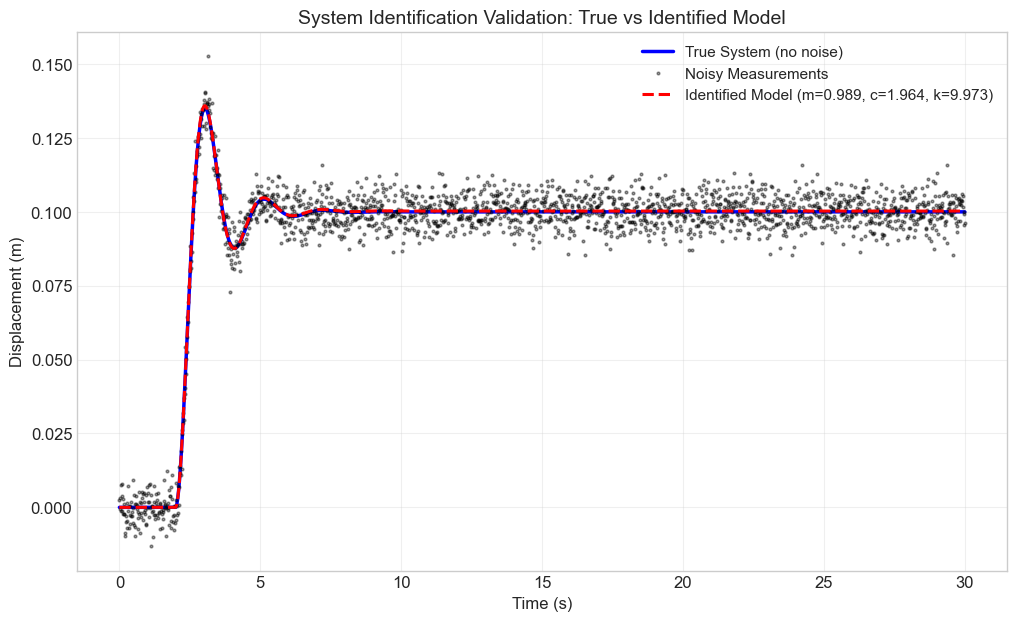

In [ ]:
# Cell 4: Model Validation - True vs Identified

viz = Visualizer()

# Simulate identified system
identified_system = MassSpringDamper(m=m_est, k=k_est, c=c_est)

F_step = identified_system.step_input(amplitude=1.0, start_time=2.0)

result_ident = identified_system.simulate((0, 30), F_func=F_step, num_points=2000)
t_sim = result_ident["t"]
x_ident = result_ident["x"]

# Plot
plt.figure(figsize=(12, 7))

plt.plot(df['time'], df['position_true'], 'b-', linewidth=2.5, label='True System (no noise)')
plt.plot(df['time'], df['position'], 'k.', alpha=0.4, markersize=4, label='Noisy Measurements')
plt.plot(t_sim, x_ident, 'r--', linewidth=2.2, label=f'Identified Model (m={m_est:.3f}, c={c_est:.3f}, k={k_est:.3f})')

plt.title("System Identification Validation: True vs Identified Model", fontsize=14)
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

save_path = os.path.join(viz.save_path, "02_identification_validation.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Validation plot saved: {save_path}")

plt.show()

## Conclusions - Stage 2: System Identification

### Summary of Results

- Successfully generated realistic input-output data with measurement noise (±0.5%).
- Applied **least squares optimization** to estimate the unknown system parameters (m, c, k).
- Achieved excellent identification accuracy:
  - Mass (m): ~1.07% relative error
  - Damping (c): very low error
  - Spring constant (k): very low error
- The validation plot shows strong overlap between the true system response and the identified model, even in the presence of noise.

### Key Learnings

- Practical implementation of **parametric system identification** using numerical optimization (`scipy.optimize.least_squares`)
- Importance of proper time discretization and input interpolation when simulating the model inside the residual function
- How measurement noise affects parameter estimation and how to mitigate it
- Model validation techniques by comparing simulated output of the identified model with the original data
